In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

os.chdir('/content/drive/MyDrive/Project/BrainRegionId/Project43/Code')
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.metrics import accu_fun

In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-35053d34-6a83-8fda-bbe2-7b1aefc226f3)


In [3]:
def dat_ind_gen_Cosmos(list_dict, subject_od_ind, key):

    train_ind = np.setdiff1d(np.intersect1d(np.argwhere(np.array(list_dict['train_list_intest']) == 1).flatten(),
                                np.argwhere(np.array(list_dict['key_list']) == key).flatten()), subject_od_ind)

    valid_ind = np.setdiff1d(np.intersect1d(np.argwhere(np.array(list_dict['valid_list_intest']) == 1).flatten(),
                                np.argwhere(np.array(list_dict['key_list']) == key).flatten()), subject_od_ind)

    test_ind = np.setdiff1d(np.intersect1d(np.argwhere(np.array(list_dict['test_list_intest']) == 1).flatten(),
                                np.argwhere(np.array(list_dict['key_list']) == key).flatten()), subject_od_ind)

    test_subject_ind = np.intersect1d(subject_od_ind, np.argwhere(np.array(list_dict['key_list']) == key).flatten())

    return train_ind, valid_ind, test_ind, test_subject_ind



In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

# dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
# acronym_list = acronym_list_gen(dict_dir)

In [5]:
# @title Load data
key = 'stimOff_times'
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
# torch.save(brain_signal_lfp, '/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')


In [6]:
list_dict = torch.load(file_dir + '/list_dict.pt', weights_only=False)
# list_dict_acronym_selec = torch.load(file_dir + '/list_dict_acronym_selec.pt')
brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']



In [7]:
subject_od_ind = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43' + f'/Model/Cosmos/subject_od_ind_Cosmos_{key}{0}.pt', weights_only=False)
subject_od_list = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43' + f'/Model/Cosmos/subject_od_list_Cosmos_{key}{0}.pt', weights_only=False)


In [8]:
ind = 0

model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Model/Cosmos'

if device.type != 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Cosmos_chance_{key}{ind}.pth', map_location=torch.device('cpu'))
    Classifier_LC = torch.load(model_dir + f'/LC_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Cosmos_{key}{ind}.pth', map_location=torch.device('cpu'))

elif device.type == 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Cosmos_chance_{key}{ind}.pth', weights_only=False).to(device)
    Classifier_LC = torch.load(model_dir + f'/LC_L_Cosmos_{key}{ind}.pth', weights_only=False).to(device)


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Cosmos_{key}{ind}.pth', weights_only=False).to(device)
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Cosmos_{key}{ind}.pth', weights_only=False).to(device)
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Cosmos_{key}{ind}.pth', weights_only=False).to(device)



In [9]:
if len(brain_signal_lfp) == len(brain_region_index_Cosmos):
    print('Matched, no damage!')

Matched, no damage!


In [ ]:
try:
    print(len(brain_region_index))
except:
    print(len(brain_region_index_Cosmos))
    print(brain_region_index_Cosmos.unique())
    print('Cosmos mapping loading>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>')

3374942


In [ ]:
list_dict['brain_region_index_Cosmos']

tensor([0, 0, 0,  ..., 9, 9, 9])

In [10]:
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen_Cosmos(list_dict, subject_od_ind, key)

data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index_Cosmos[test_ind], coordinate_list[test_ind])

test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

In [11]:
c0 = 64 * 4
k0 = 1.0

model_args = {
    'arch':((2,c0 * 2,1,k0), (2,c0 * 3,1,k0), (2,c0 * 4,1,k0), (2,c0 * 5,1,k0)),
    'stem_channels':c0,
}
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    'epochs':50,
    'save_dir':'/content/drive/MyDrive/Project/BrainRegionId/Project43',
}


In [ ]:
model_type = []
acu_test = []
Classifier_name = ['Chance',  'Linear', 'AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate([Classifier_LCC, Classifier_LC, Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
    Classifier.eval()
    for x_test1, y_test, coordinate_test in test_iter:
        if Classifier_name[Classifier_ii] == 'RNN':
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        else:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])
    print(Classifier_ii)


acu = pd.DataFrame({
    'acu_test': np.array(acu_test),
    'model_type': model_type,
})

0
1
2
3
4


In [ ]:
torch.save(acu, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict.pt')

<ipython-input-17-a2ff35c92907>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(


Text(0.5, 1.0, 'stimOff_times (Cosmos)')

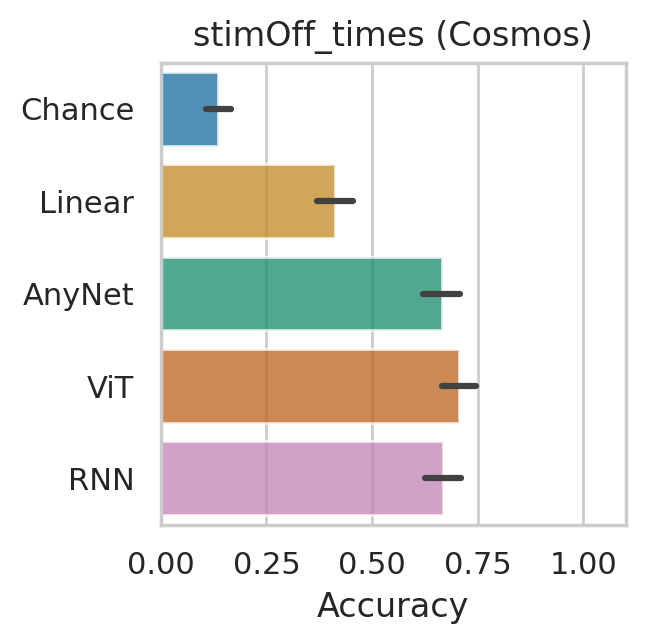

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(3, 3), dpi=200)
g = sns.barplot(
    data=acu,
    x='acu_test', y='model_type',
    errorbar='sd', palette='colorblind', alpha=.75
)
plt.xlim([0, 1.1])
plt.ylabel('')
plt.xlabel('Accuracy')
plt.title(f'{key} (Cosmos)')

In [12]:
# data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index_Cosmos[test_ind], coordinate_list[test_ind])
test_subject_ind1 = np.random.choice(test_subject_ind, 128 * 200, replace=False)
data_test_subject1 = TensorDataset(brain_signal_lfp[test_subject_ind1,:], brain_region_index_Cosmos[test_subject_ind1], coordinate_list[test_subject_ind1])

test_iter_subject1 = DataLoader(data_test_subject1, batch_size=128, shuffle=True)


In [13]:
model_type = []
acu_test_subject = []
Classifier_name = ['Chance',  'Linear', 'AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate([Classifier_LCC, Classifier_LC, Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
    Classifier.eval()
    for x_test1, y_test, coordinate_test in test_iter_subject1:
        if Classifier_name[Classifier_ii] == 'RNN':
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
            del x_test, x_test1
            acu_test_subject.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
            del x_test, x_test1
            acu_test_subject.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        else:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device))
            del x_test, x_test1
            acu_test_subject.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])
    print(Classifier_ii)


acu_subject = pd.DataFrame({
    'acu_test_subject': np.array(acu_test_subject),
    'model_type': model_type,
})

0
1
2
3
4


In [14]:
torch.save(acu_subject, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict_subject.pt')

<ipython-input-36-e82dc3c0cd42>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(


Text(0.5, 1.0, 'Electro(subject)')

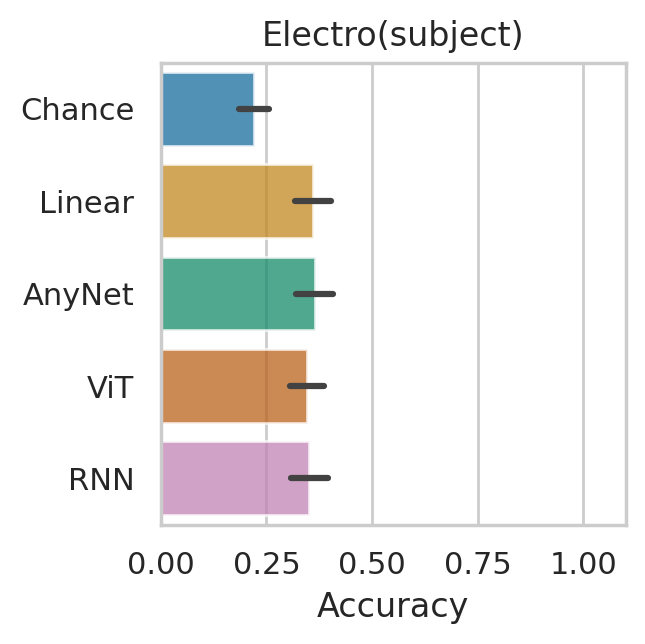

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(3, 3), dpi=200)
g = sns.barplot(
    data=acu_subject,
    x='acu_test_subject', y='model_type',
    errorbar='sd', palette='colorblind', alpha=.75
)
plt.xlim([0, 1.1])
plt.ylabel('')
plt.xlabel('Accuracy')
plt.title('Electro(subject)')

In [16]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader

from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:02<00:00, 10.96it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  2.65it/s]


In [17]:
cosmos_indices = np.unique(br.mappings['Cosmos'])
acronym_list_Cosmos = [acronym for acronym in br.acronym[cosmos_indices] if acronym != 'void' and acronym != 'root']
print(acronym_list_Cosmos)

['Isocortex', 'OLF', 'HPF', 'CTXsp', 'CNU', 'TH', 'HY', 'MB', 'HB', 'CB']


In [ ]:
np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == 1).flatten()

array([ 865018,  865019,  865020, ..., 2663959, 2663960, 2663961])

In [18]:
acu_test_subject = []
acronym_subject_test = []
model_name = []
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list_Cosmos):
        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == acronym_ii).flatten(), test_subject_ind)
        print(len(test_ind_acronym_ii))
        print(acronym)

196677
Isocortex
35016
OLF
66819
HPF
12633
CTXsp
81810
CNU
99472
TH
13600
HY
84023
MB
73165
HB
57490
CB
196677
Isocortex
35016
OLF
66819
HPF
12633
CTXsp
81810
CNU
99472
TH
13600
HY
84023
MB
73165
HB
57490
CB
196677
Isocortex
35016
OLF
66819
HPF
12633
CTXsp
81810
CNU
99472
TH
13600
HY
84023
MB
73165
HB
57490
CB


In [19]:
acu_test_subject = []
acronym_subject_test = []
model_name = []
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list_Cosmos):
        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == acronym_ii).flatten(), test_subject_ind)
        if len(test_ind_acronym_ii) < 1:
            # print(acronym)
            continue
        else:

            test_indiv = np.random.choice(test_ind_acronym_ii, 128*50, replace=False)
            data_test_indiv = TensorDataset(brain_signal_lfp[test_indiv,:], brain_region_index_Cosmos[test_indiv])
            test_iter_indiv = DataLoader(data_test_indiv, batch_size=128, shuffle=True)

            for x_test1, y_test in test_iter_indiv:

                x_test = lfp_spectro(x_test1, spectro_args, train_args)
                y_test = y_test.to(device)


                if Classifier_name[Classifier_ii] == 'RNN':
                    py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
                elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
                    py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
                else:
                    py_test = Classifier(x_test.to(device))

                # print(acronym, f'acu: {(torch.sum(torch.argmax(py_test, dim=1) == y_test) / y_test.size(0)).detach().cpu()}')
                acronym_subject_test.append(acronym)

                acu_test_subject.append(accu_fun(py_test, y_test))

                model_name.append(Classifier_name[Classifier_ii])

    print(f'Classifier index: {Classifier_ii}')


Classifier index: 0
Classifier index: 1
Classifier index: 2


In [20]:
import pandas as pd
acu_acronym_subject = pd.DataFrame({
    'acu_test_subject': np.array(acu_test_subject),
    'model_type': model_name,
    'acronym_subject_test': acronym_subject_test,
})


In [21]:
torch.save(acu_acronym_subject, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict_acronym_subject.pt')

<ipython-input-21-8131c334e111>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


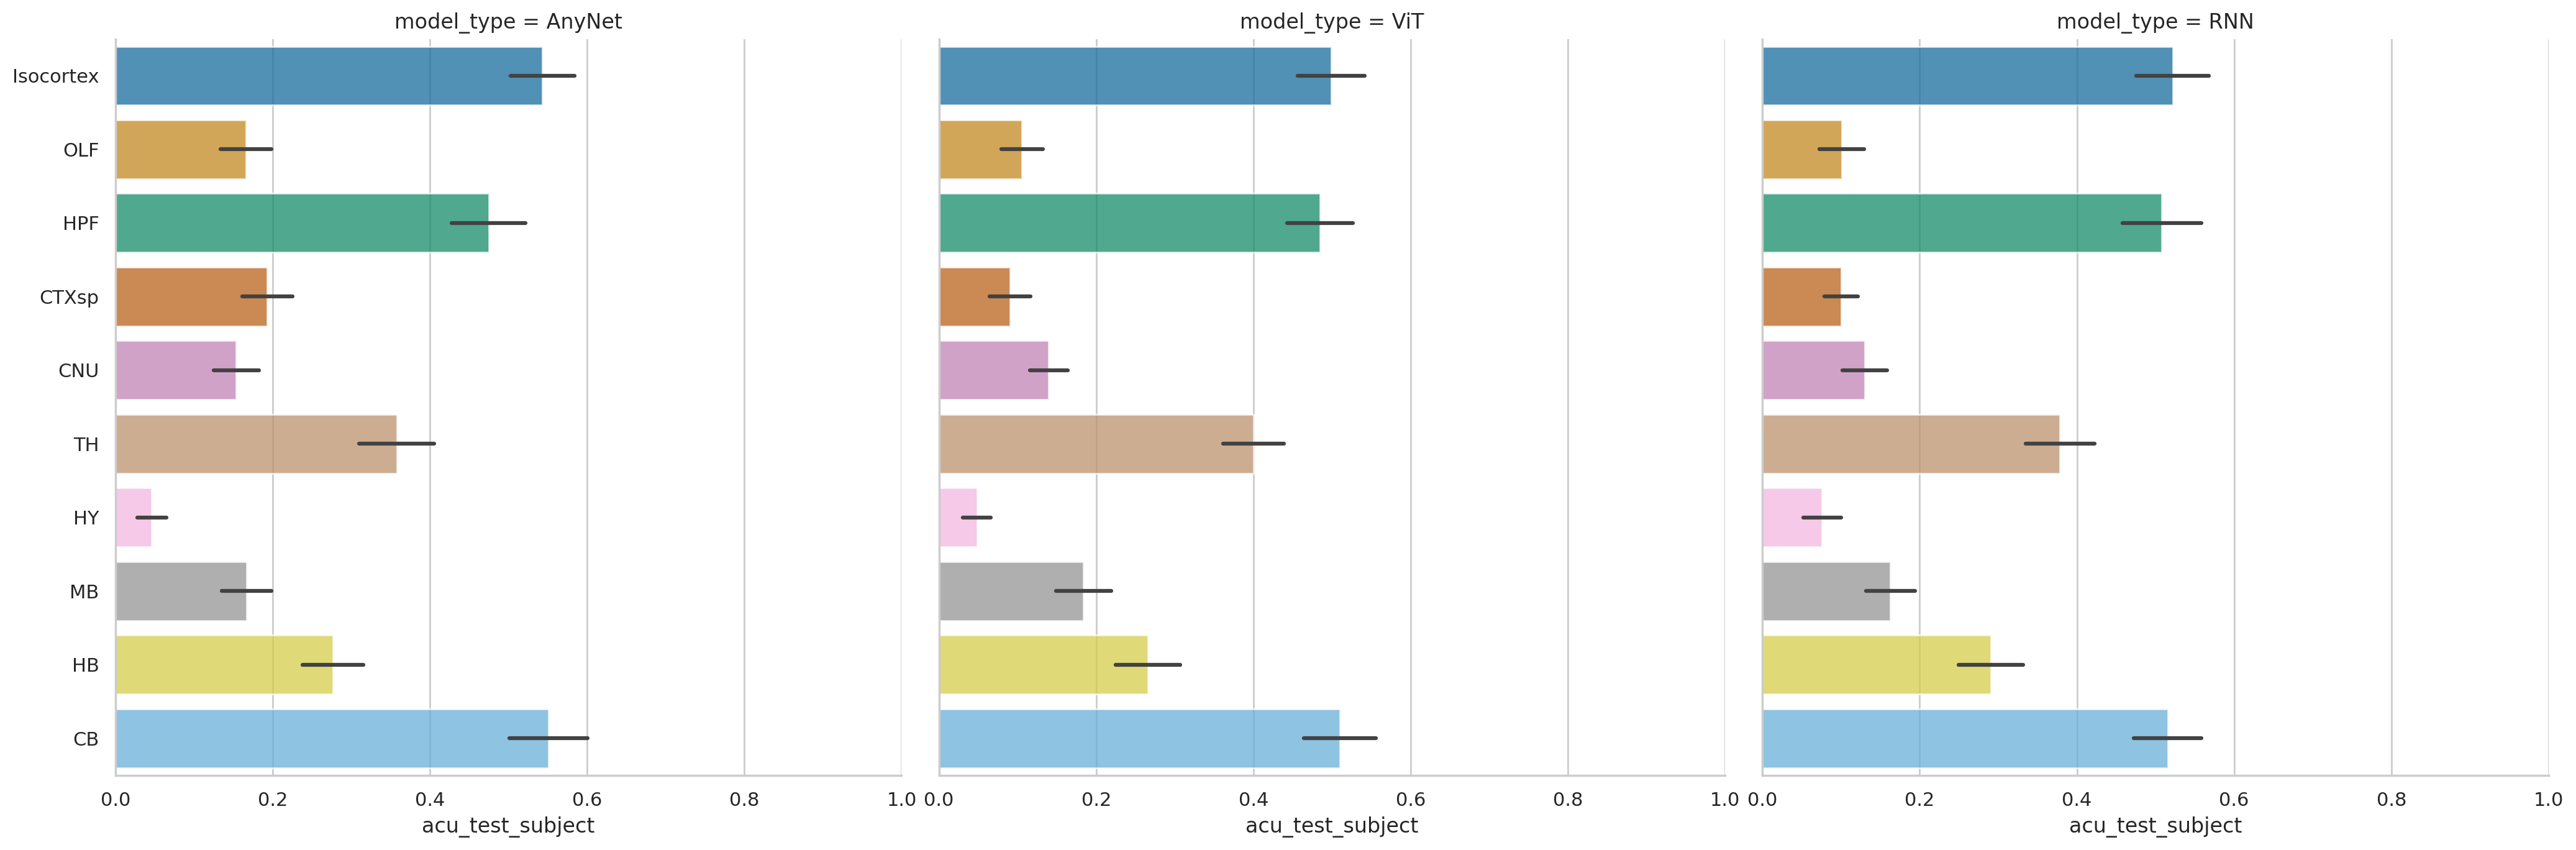

In [ ]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
g = sns.catplot(
    data=acu_subject, kind='bar',
    x='acu_test_subject', y='acronym_subject_test', col='model_type',
    errorbar='sd', palette='colorblind', alpha=.75, height=7
)
g.set(xlim=[0, 1])
g.set(ylabel='')

In [22]:
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
acu_test = []
acronym_test = []
model_name = []
for Classifier_ii, Classifier in enumerate(Classifier_list):
    for acronym_ii, acronym in enumerate(acronym_list_Cosmos):

        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == acronym_ii).flatten(), test_ind)

        if len(test_ind_acronym_ii) < 1:
            # print(acronym)
            continue
        else:

            test_indiv = test_ind_acronym_ii
            data_test_indiv = TensorDataset(brain_signal_lfp[test_indiv,:], brain_region_index_Cosmos[test_indiv])
            test_iter_indiv = DataLoader(data_test_indiv, batch_size=128, shuffle=True)

            for x_test1, y_test in test_iter_indiv:

                x_test = lfp_spectro(x_test1, spectro_args, train_args)
                y_test = y_test.to(device)


                if Classifier_name[Classifier_ii] == 'RNN':
                    py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
                elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
                    py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
                else:
                    py_test = Classifier(x_test.to(device))

                # print(acronym, f'acu: {(torch.sum(torch.argmax(py_test, dim=1) == y_test) / y_test.size(0)).detach().cpu()}')
                acronym_test.append(acronym)

                acu_test.append(accu_fun(py_test, y_test))

                model_name.append(Classifier_name[Classifier_ii])


acu_acronym_test = pd.DataFrame({
    'acu_test': np.array(acu_test),
    'model_type': model_name,
    'acronym_test': acronym_test,
})


In [23]:
torch.save(acu_acronym_test, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/accu/Cosmos_dict_acronym.pt')

<ipython-input-24-cd17c9770114>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


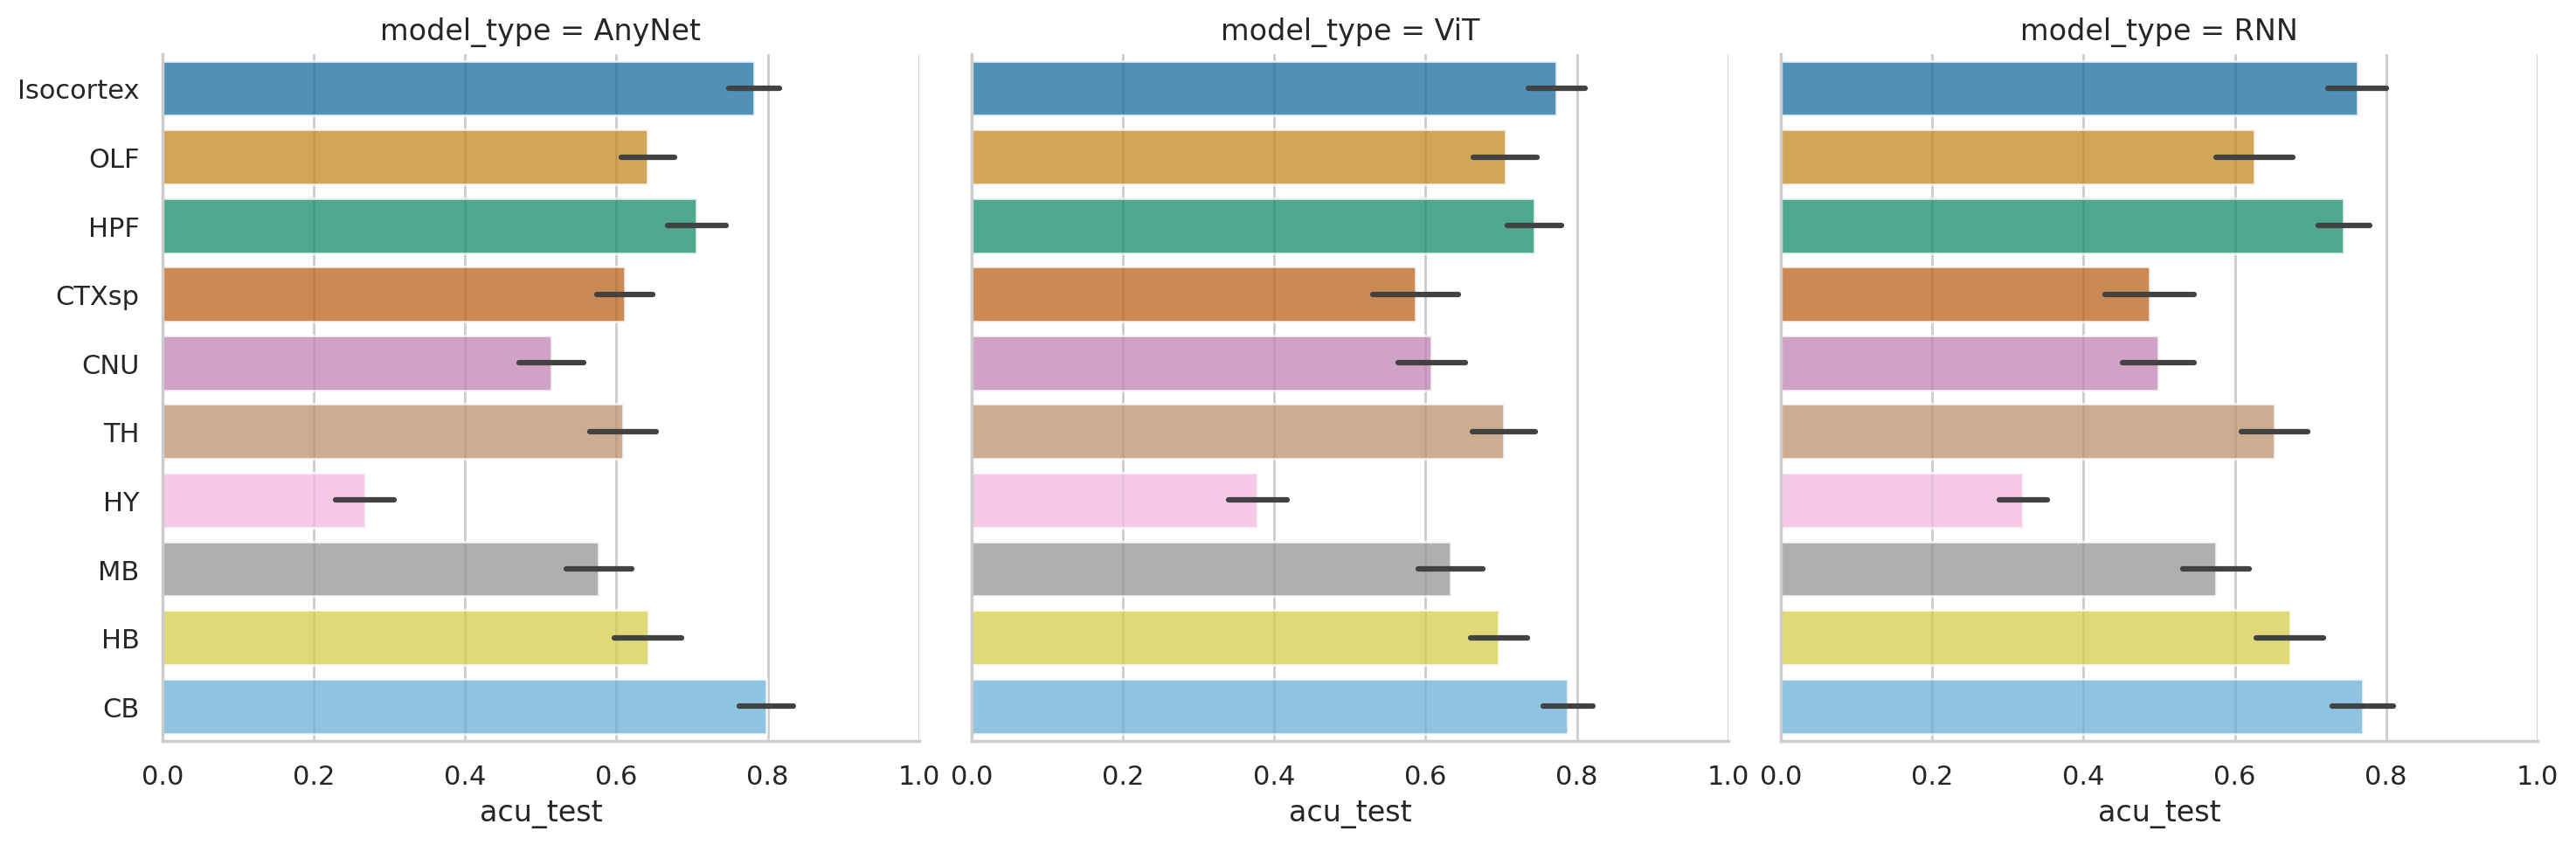

In [ ]:
sns.set_theme(rc={'figure.dpi': 200}, style='whitegrid')
g = sns.catplot(
    data=acu_test, kind='bar',
    x='acu_test', y='acronym_test', col='model_type',
    errorbar='sd', palette='colorblind', alpha=.75
)
g.set(xlim=[0, 1])
g.set(ylabel='')

In [ ]:
sample_num = 128
Classifier_name = ['AnyNet', 'ViT', 'RNN']
Classifier_list = [Classifier_AnyNet, Classifier_ViT, Classifier_RNN]
Mat_dict = {}
for Classifier_ii, Classifier in enumerate(Classifier_list):
    confusion_mat = np.zeros((len(acronym_list_Cosmos), len(acronym_list_Cosmos)))
    for acronym_ii, acronym in enumerate(acronym_list_Cosmos):

        test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_index_Cosmos']) == acronym_ii).flatten(), test_ind)

        if len(test_ind_acronym_ii) < 1:
            continue
        elif len(test_ind_acronym_ii) < sample_num:
            test_indiv = test_ind_acronym_ii
        elif len(test_ind_acronym_ii) >= sample_num:
            test_indiv = test_ind_acronym_ii[np.random.choice(len(test_ind_acronym_ii), sample_num, replace=False)]

        y_test = brain_region_index[test_indiv]
        x_test = lfp_spectro(brain_signal_lfp[test_indiv,:], spectro_args, train_args)

        if Classifier_name[Classifier_ii] == 'RNN':
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
        else:
            py_test = Classifier(x_test.to(device))
        p, edg = torch.histogram(torch.argmax(py_test.cpu(), dim=1).to(torch.float32), bins=len(acronym_list_Cosmos), range=(0, len(acronym_list_Cosmos)), density=True)
        confusion_mat[acronym_ii, :] = np.round(p.detach().cpu().numpy(), 2)
        print(acronym_ii)
    Mat_dict[Classifier_name[Classifier_ii]] = confusion_mat



0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9


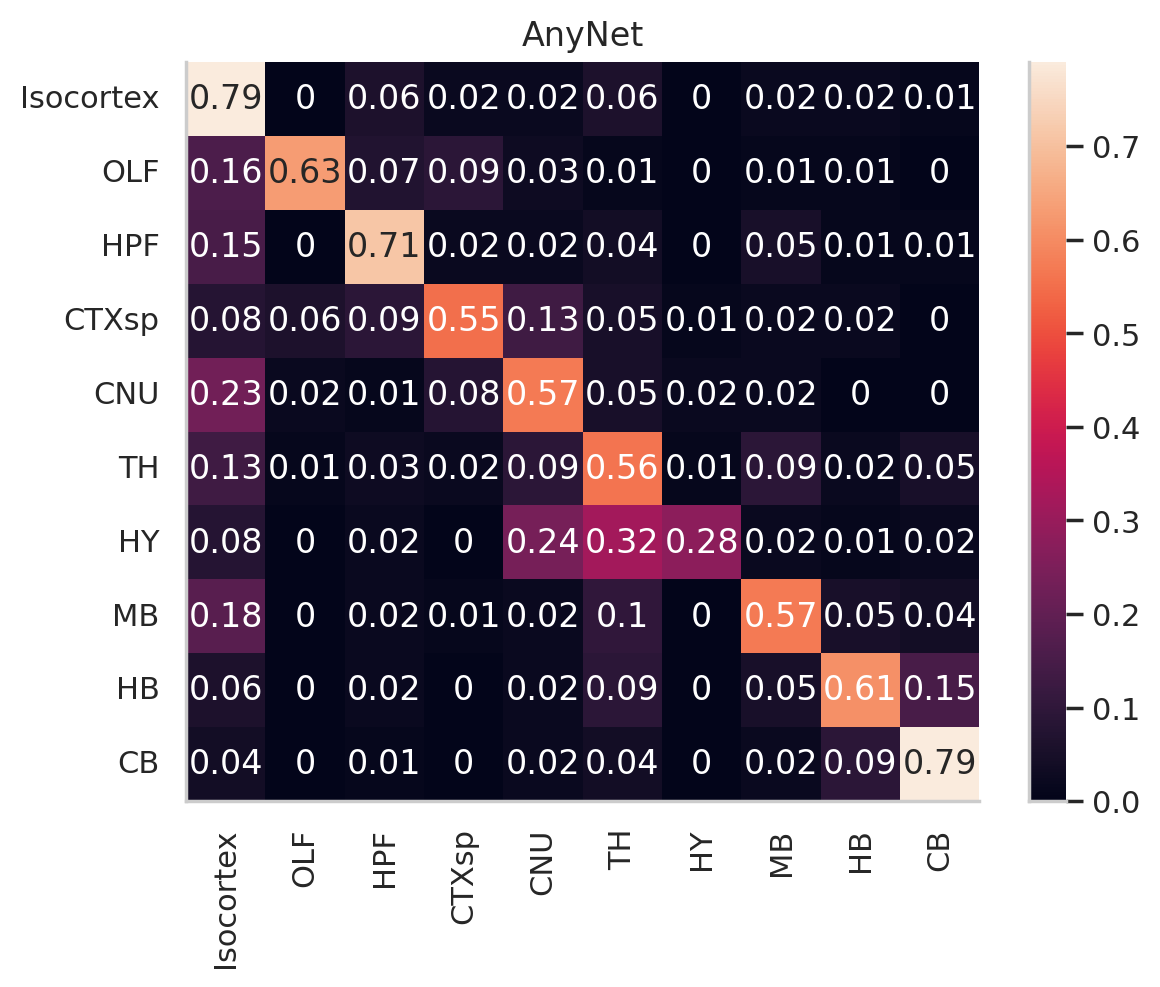

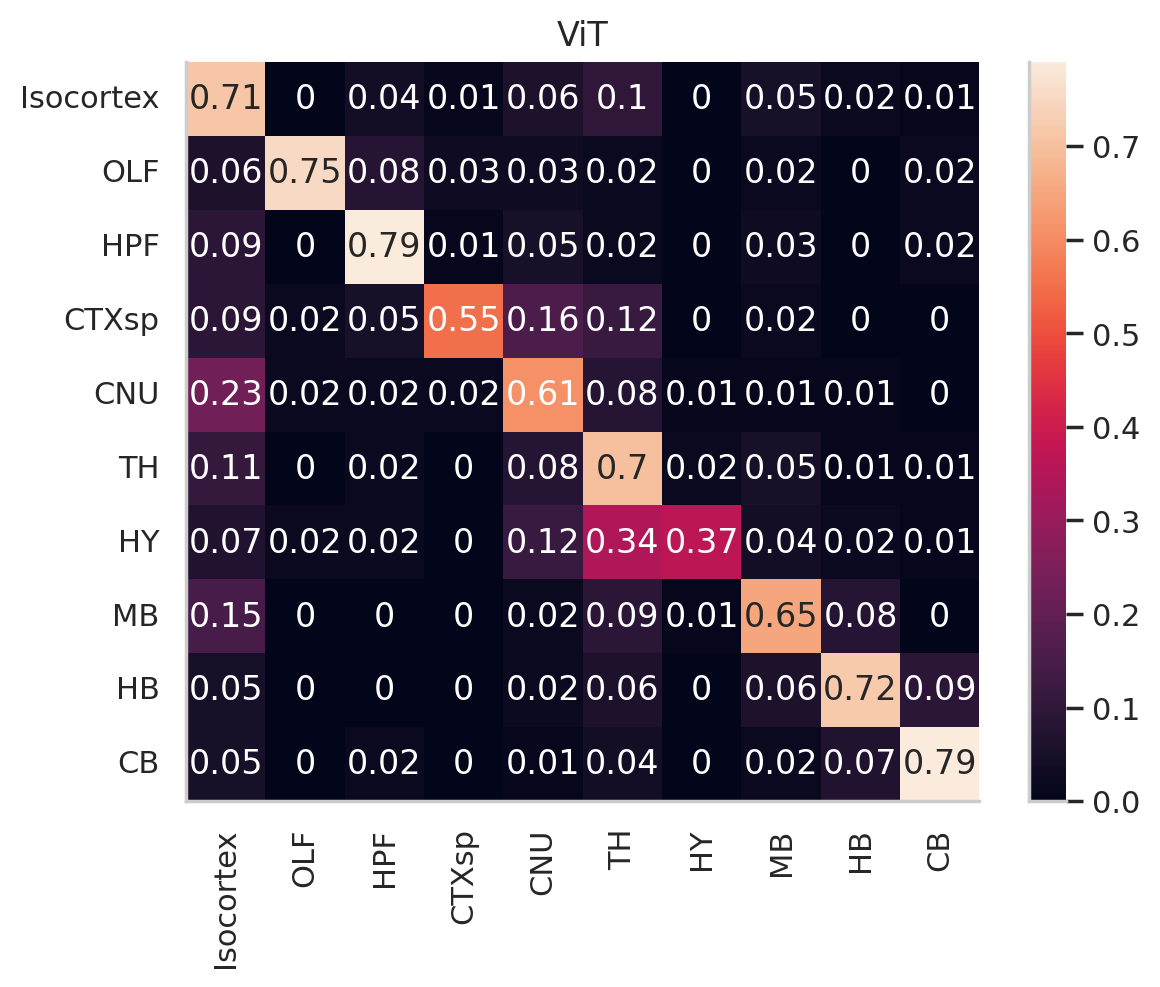

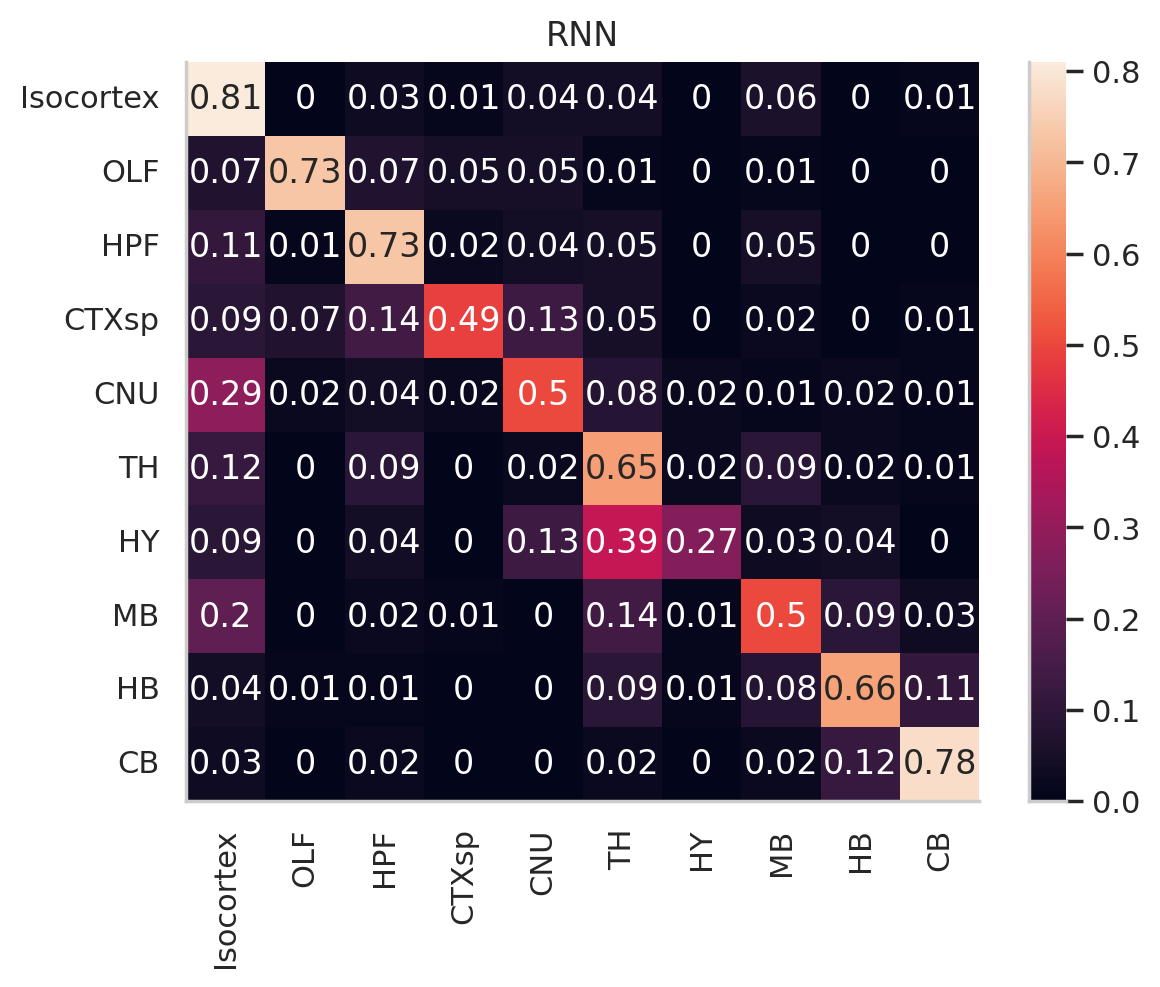

In [ ]:
for Classifier_ii, Classifier in enumerate(Classifier_list):
    plt.figure(dpi=200)
    sns.heatmap(Mat_dict[Classifier_name[Classifier_ii]], annot=True)
    sns.despine()
    plt.yticks(np.arange(0, len(acronym_list_Cosmos)) + 0.5, acronym_list_Cosmos, rotation=0)
    plt.xticks(np.arange(0, len(acronym_list_Cosmos)) + 0.5, acronym_list_Cosmos, rotation=90)
    plt.title(Classifier_name[Classifier_ii])


In [ ]:
from google.colab import runtime
runtime.unassign()